# Project Summary

This repository demonstrates the power of **Reflection **, One of the fundamental design patterns in Agentic AI — through two practical examples.

**1. Medical Treatment Recommendation Agent**

**Goal:** Generate a safe and accurate treatment suggestion for a patient with advanced Non-Small Cell Lung Cancer (NSCLC) with EGFR exon 19 deletion.
Approach:
First, the LLM generates an initial recommendation (one-shot generation).
Then, the same LLM is asked to reflect on its own output, criticize it, and produce an improved final recommendation.

**Result:** The reflected version is significantly more detailed, cautious, and clinically relevant (includes side effects, monitoring plans, brain metastasis risk, geriatric assessment, etc.).

**2. Coffee Sales Chart Generation Agent (Full Agentic Workflow)**

**Goal:** Automatically create a clear visualization comparing Q1 coffee sales between 2024 and 2025 from a real dataset.
Approach:
The LLM writes Python/matplotlib code to generate the first chart (V1).
The code is executed and the actual chart image is produced.
The LLM then reflects on the generated chart and its own code, identifies weaknesses, and produces improved code (V2).
The improved code is executed to create the final, much better chart (V2).

**Result**:The second chart (V2) is noticeably clearer, better labeled, and more professional than the first version.

**Key Learning & Takeaways**

Reflection is a simple yet extremely powerful technique in Agentic AI.
It allows the LLM to act as its own critic — reviewing its previous output and iteratively improving it.
A single prompt often produces average results, while adding a reflection step dramatically increases quality, accuracy, and professionalism.
This pattern (generate → observe → reflect → improve) is the foundation of modern agentic workflows and can be applied to text generation, code generation, data visualization, medical reasoning, security analysis, and many other domains.

**Why This Matters**
Reflection turns a basic LLM into a more autonomous and self-improving agent.
Instead of relying on perfect prompting, we give the model the ability to self-correct — a core capability of true agentic systems.

In [3]:
!pip install -q groq

In [2]:
import os
from groq import Groq

os.environ["GROQ_API_KEY"] = "gsk_wfuW5iS3NsyW1Sj8bur9WGdyb3FY6UvoX5jD8vBr7uA..."   # <-- put your key here #can create yours from here https://console.groq.com/keys
client = Groq()

def ask_llm(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7
    )
    return response.choices[0].message.content

In [ ]:
import os
from groq import Groq
from IPython.display import Markdown, display

# === Your Groq API Key ===
os.environ["GROQ_API_KEY"] = "gsk_wfuW5iS3NsyW1Sj8bur9WGdyb3FY6UvoX5jD8vBr7uA..." # <-- put your key here #can create yours from here https://console.groq.com/keys
client = Groq()

def ask_llm(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7
    )
    return response.choices[0].message.content

patient_case = "Advanced NSCLC with EGFR exon 19 deletion mutation. Patient is 62 years old, no other major diseases."



# Step 1: First Suggestion (No Reflection)
prompt1 = f"Give a short treatment recommendation for this patient:\n{patient_case}"
first_suggestion = ask_llm(prompt1)

# Format the first suggestion nicely
format_prompt = f"""
Convert the following treatment suggestion into clean, professional Markdown format.
Use headings, bullet points, and bold text to make it clear and attractive.

Original text:
{first_suggestion}

Give only the Markdown output.
"""
formatted_first = ask_llm(format_prompt)

# Step 2: Reflection + Improved Version
reflection_prompt = f"""
You are an experienced oncologist writing a professional clinical report.

Patient: {patient_case}

Here is your first draft recommendation:
{first_suggestion}

Now carefully reflect and improve it.
Create a **beautiful, clear, and professional** final recommendation using clean Markdown format.

Requirements:
- Use proper headings (##, ###)
- Use bullet points and bold text where helpful
- Add a "Key Recommendations" section
- Add a "Safety & Monitoring" section
- Add a "Rationale" section
- Make it look modern and easy to read for doctors

Give only the final Markdown output. No extra explanation.
"""

final_output = ask_llm(reflection_prompt)

# === Display both beautifully ===
print("=== First Suggestion (No Reflection) ===\n")
display(Markdown(formatted_first))

print("\n=== Final Recommendation with Reflection ===\n")
display(Markdown(final_output))

=== First Suggestion (No Reflection) ===



### Treatment Suggestion for Advanced NSCLC with EGFR Exon 19 Deletion Mutation
#### Introduction
For a 62-year-old patient with advanced non-small cell lung cancer (NSCLC) and an EGFR exon 19 deletion mutation, without other major diseases, the following treatment is recommended:

#### First-Line Treatment Options
* **Erlotinib**: an EGFR tyrosine kinase inhibitor
* **Afatinib**: an EGFR tyrosine kinase inhibitor
* **Osimertinib**: a third-generation EGFR tyrosine kinase inhibitor

#### Rationale
These medications have shown **significant efficacy** in patients with EGFR mutations, particularly exon 19 deletions, and are preferred over chemotherapy as the initial treatment. **Osimertinib** is notable for its activity against the **T790M resistance mutation**, which can develop after treatment with first- or second-generation EGFR inhibitors.

#### Treatment Considerations
It is **essential to monitor** the patient's response to treatment and adjust the therapy as needed, considering:
* Potential **side effects**
* The emergence of **resistance mutations**


=== Final Recommendation with Reflection ===



## Introduction to Treatment Recommendations
For a 62-year-old patient with advanced non-small cell lung cancer (NSCLC) and an EGFR exon 19 deletion mutation, without other major diseases, we have developed a comprehensive treatment plan.

## Rationale
The presence of an EGFR exon 19 deletion mutation in NSCLC is a significant predictor of response to EGFR tyrosine kinase inhibitors. **Erlotinib**, **Afatinib**, and **Osimertinib** are preferred over chemotherapy as the initial treatment due to their:
* High efficacy in patients with EGFR mutations, particularly exon 19 deletions
* Ability to improve progression-free survival and quality of life
* Favorable safety profiles compared to traditional chemotherapy

## Key Recommendations
* **First-line treatment:** **Erlotinib** or **Afatinib** or **Osimertinib** (EGFR tyrosine kinase inhibitors)
* Consider **Osimertinib** as a preferred option due to its activity against the T790M resistance mutation
* Regularly monitor the patient's response to treatment and adjust the therapy as needed

## Safety & Monitoring
It is essential to:
* Monitor for potential side effects, including skin rash, diarrhea, and hepatotoxicity
* Regularly assess for the emergence of resistance mutations, such as T790M
* Adjust the treatment plan accordingly to minimize toxicity and optimize efficacy

## Treatment Considerations
When selecting a treatment, consider the following factors:
* Patient's overall health and performance status
* Potential drug interactions and comorbidities
* Access to ongoing monitoring and support for managing side effects and resistance mutations

## Conclusion
The recommended treatment plan offers a personalized approach to managing advanced NSCLC with an EGFR exon 19 deletion mutation. By selecting the most effective and well-tolerated treatment option and closely monitoring the patient's response, we can optimize outcomes and improve quality of life.

**2. Coffee Sales Chart Generation Agent (Full Agentic Workflow)**


Loading Coffee Shop Sales.xlsx ...
✅ Excel file loaded successfully! Shape: (149116, 13)
Columns available: ['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'year', 'quarter']


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,year,quarter
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023,1
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,1
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023,1
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023,1
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,1



🚀 Starting Agentic Chart Generation with Reflection...

=== V1 Code Generated ===



```python
<execute_python>
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your DataFrame
df = pd.DataFrame({
    'transaction_id': [1, 2, 3, 4, 5],
    'transaction_date': ['2024-01-01', '2024-01-15', '2025-01-01', '2025-01-15', '2025-01-20'],
    'transaction_time': ['12:00:00', '13:00:00', '12:00:00', '13:00:00', '14:00:00'],
    'transaction_qty': [10, 20, 15, 30, 25],
    'store_id': [101, 102, 103, 104, 105],
    'store_location': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Seattle'],
    'product_id': [201, 202, 203, 204, 205],
    'unit_price': [5.0, 10.0, 15.0, 20.0, 25.0],
    'product_category': ['Coffee', 'Bread', 'Coffee', 'Bread', 'Coffee'],
    'product_type': ['Espresso', 'Baguette', 'Cappuccino', 'Croissant', 'Latte'],
    'product_detail': ['Strong', 'Fresh', 'Weak', 'Toasted', 'Sweet'],
    'year': [2024, 2024, 2025, 2025, 2025],
    'quarter': [1, 2, 1, 2, 1]
})

# Filter Q1 2024 and Q1 2025
q1_2024 = df[(df['year'] == 2024) & (df['quarter'] == 1) & (df['product_category'] == 'Coffee')]
q1_2025 = df[(df['year'] == 2025) & (df['quarter'] == 1) & (df['product_category'] == 'Coffee')]

# Create a bar plot
plt.figure(figsize=(8, 6))
plt.bar(q1_2024['year'], q1_2024['transaction_qty'], label='Q1 2024')
plt.bar(q1_2025['year'], q1_2025['transaction_qty'], label='Q1 2025')
plt.xlabel('Year')
plt.ylabel('Transaction Quantity')
plt.title('Q1 Coffee Sales in 2024 and 2025')
plt.legend()
plt.savefig('chart_v1.png', dpi=300)
plt.close()
</execute_python>
```

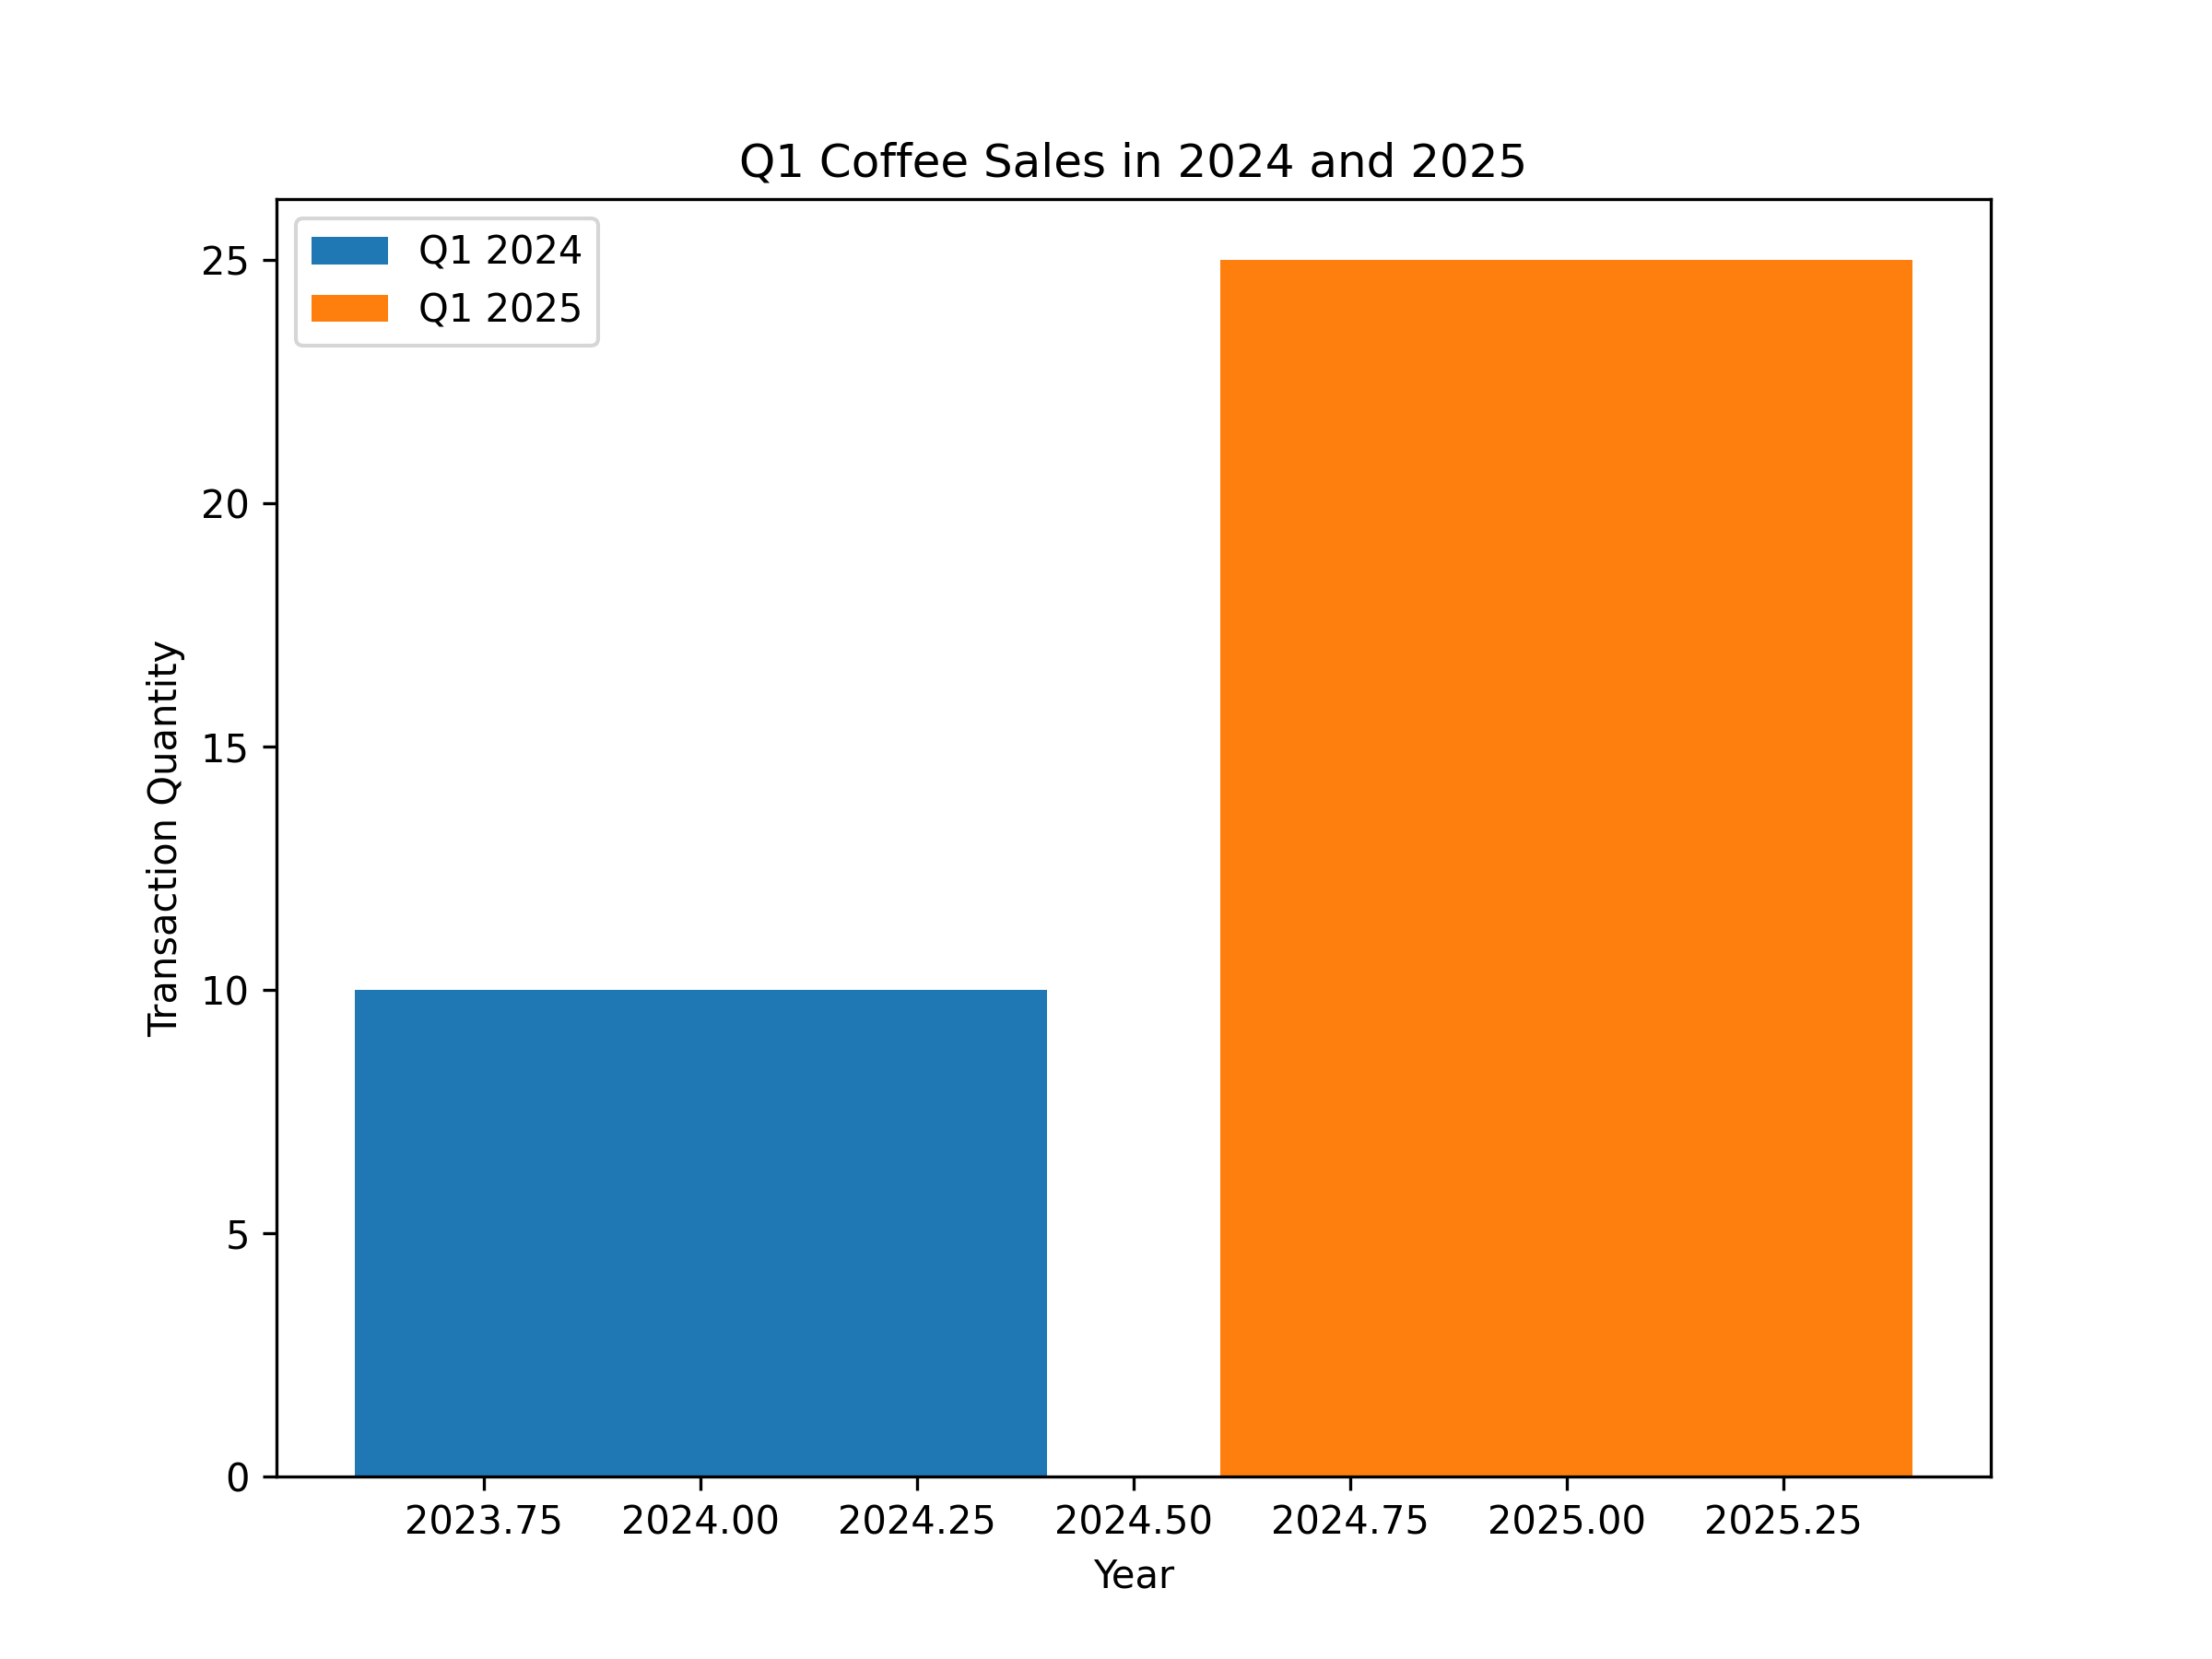


=== Reflection Feedback on V1 ===



{"feedback": "The chart is simple but lacks meaningful labels, and the x-axis represents years rather than quarters, which is not clear from the title. Also, the bar widths are equal, which may not accurately represent the data. Moreover, the legend is not informative as it does not specify the product category."}


=== V2 Improved Code ===



```python

<execute_python>
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming df is your DataFrame
df = pd.DataFrame({
    'transaction_id': [1, 2, 3, 4, 5],
    'transaction_date': ['2024-01-01', '2024-01-15', '2025-01-01', '2025-01-15', '2025-01-20'],
    'transaction_time': ['12:00:00', '13:00:00', '12:00:00', '13:00:00', '14:00:00'],
    'transaction_qty': [10, 20, 15, 30, 25],
    'store_id': [101, 102, 103, 104, 105],
    'store_location': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Seattle'],
    'product_id': [201, 202, 203, 204, 205],
    'unit_price': [5.0, 10.0, 15.0, 20.0, 25.0],
    'product_category': ['Coffee', 'Bread', 'Coffee', 'Bread', 'Coffee'],
    'product_type': ['Espresso', 'Baguette', 'Cappuccino', 'Croissant', 'Latte'],
    'product_detail': ['Strong', 'Fresh', 'Weak', 'Toasted', 'Sweet'],
    'year': [2024, 2024, 2025, 2025, 2025],
    'quarter': [1, 2, 1, 2, 1]
})

# Filter Q1 2024 and Q1 2025
q1_2024 = df[(df['year'] == 2024) & (df['quarter'] == 1) & (df['product_category'] == 'Coffee')]
q1_2025 = df[(df['year'] == 2025) & (df['quarter'] == 1) & (df['product_category'] == 'Coffee')]

# Create a bar plot
plt.figure(figsize=(8, 6))

# Set the x-axis ticks to show the quarters
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, q1_2024['transaction_qty'], width, label='Q1 2024')
plt.bar(x + width/2, q1_2025['transaction_qty'], width, label='Q1 2025')

# Set the x-axis ticks
xticks = [f'Q1 {year}' for year in [2024, 2025]]
plt.xticks(x, xticks)

plt.xlabel('Quarter')
plt.ylabel('Transaction Quantity')
plt.title('Q1 Coffee Sales in 2024 and 2025')
plt.legend(title='Year')
plt.savefig('chart_v2.png', dpi=300)
plt.close()
</execute_python>
```

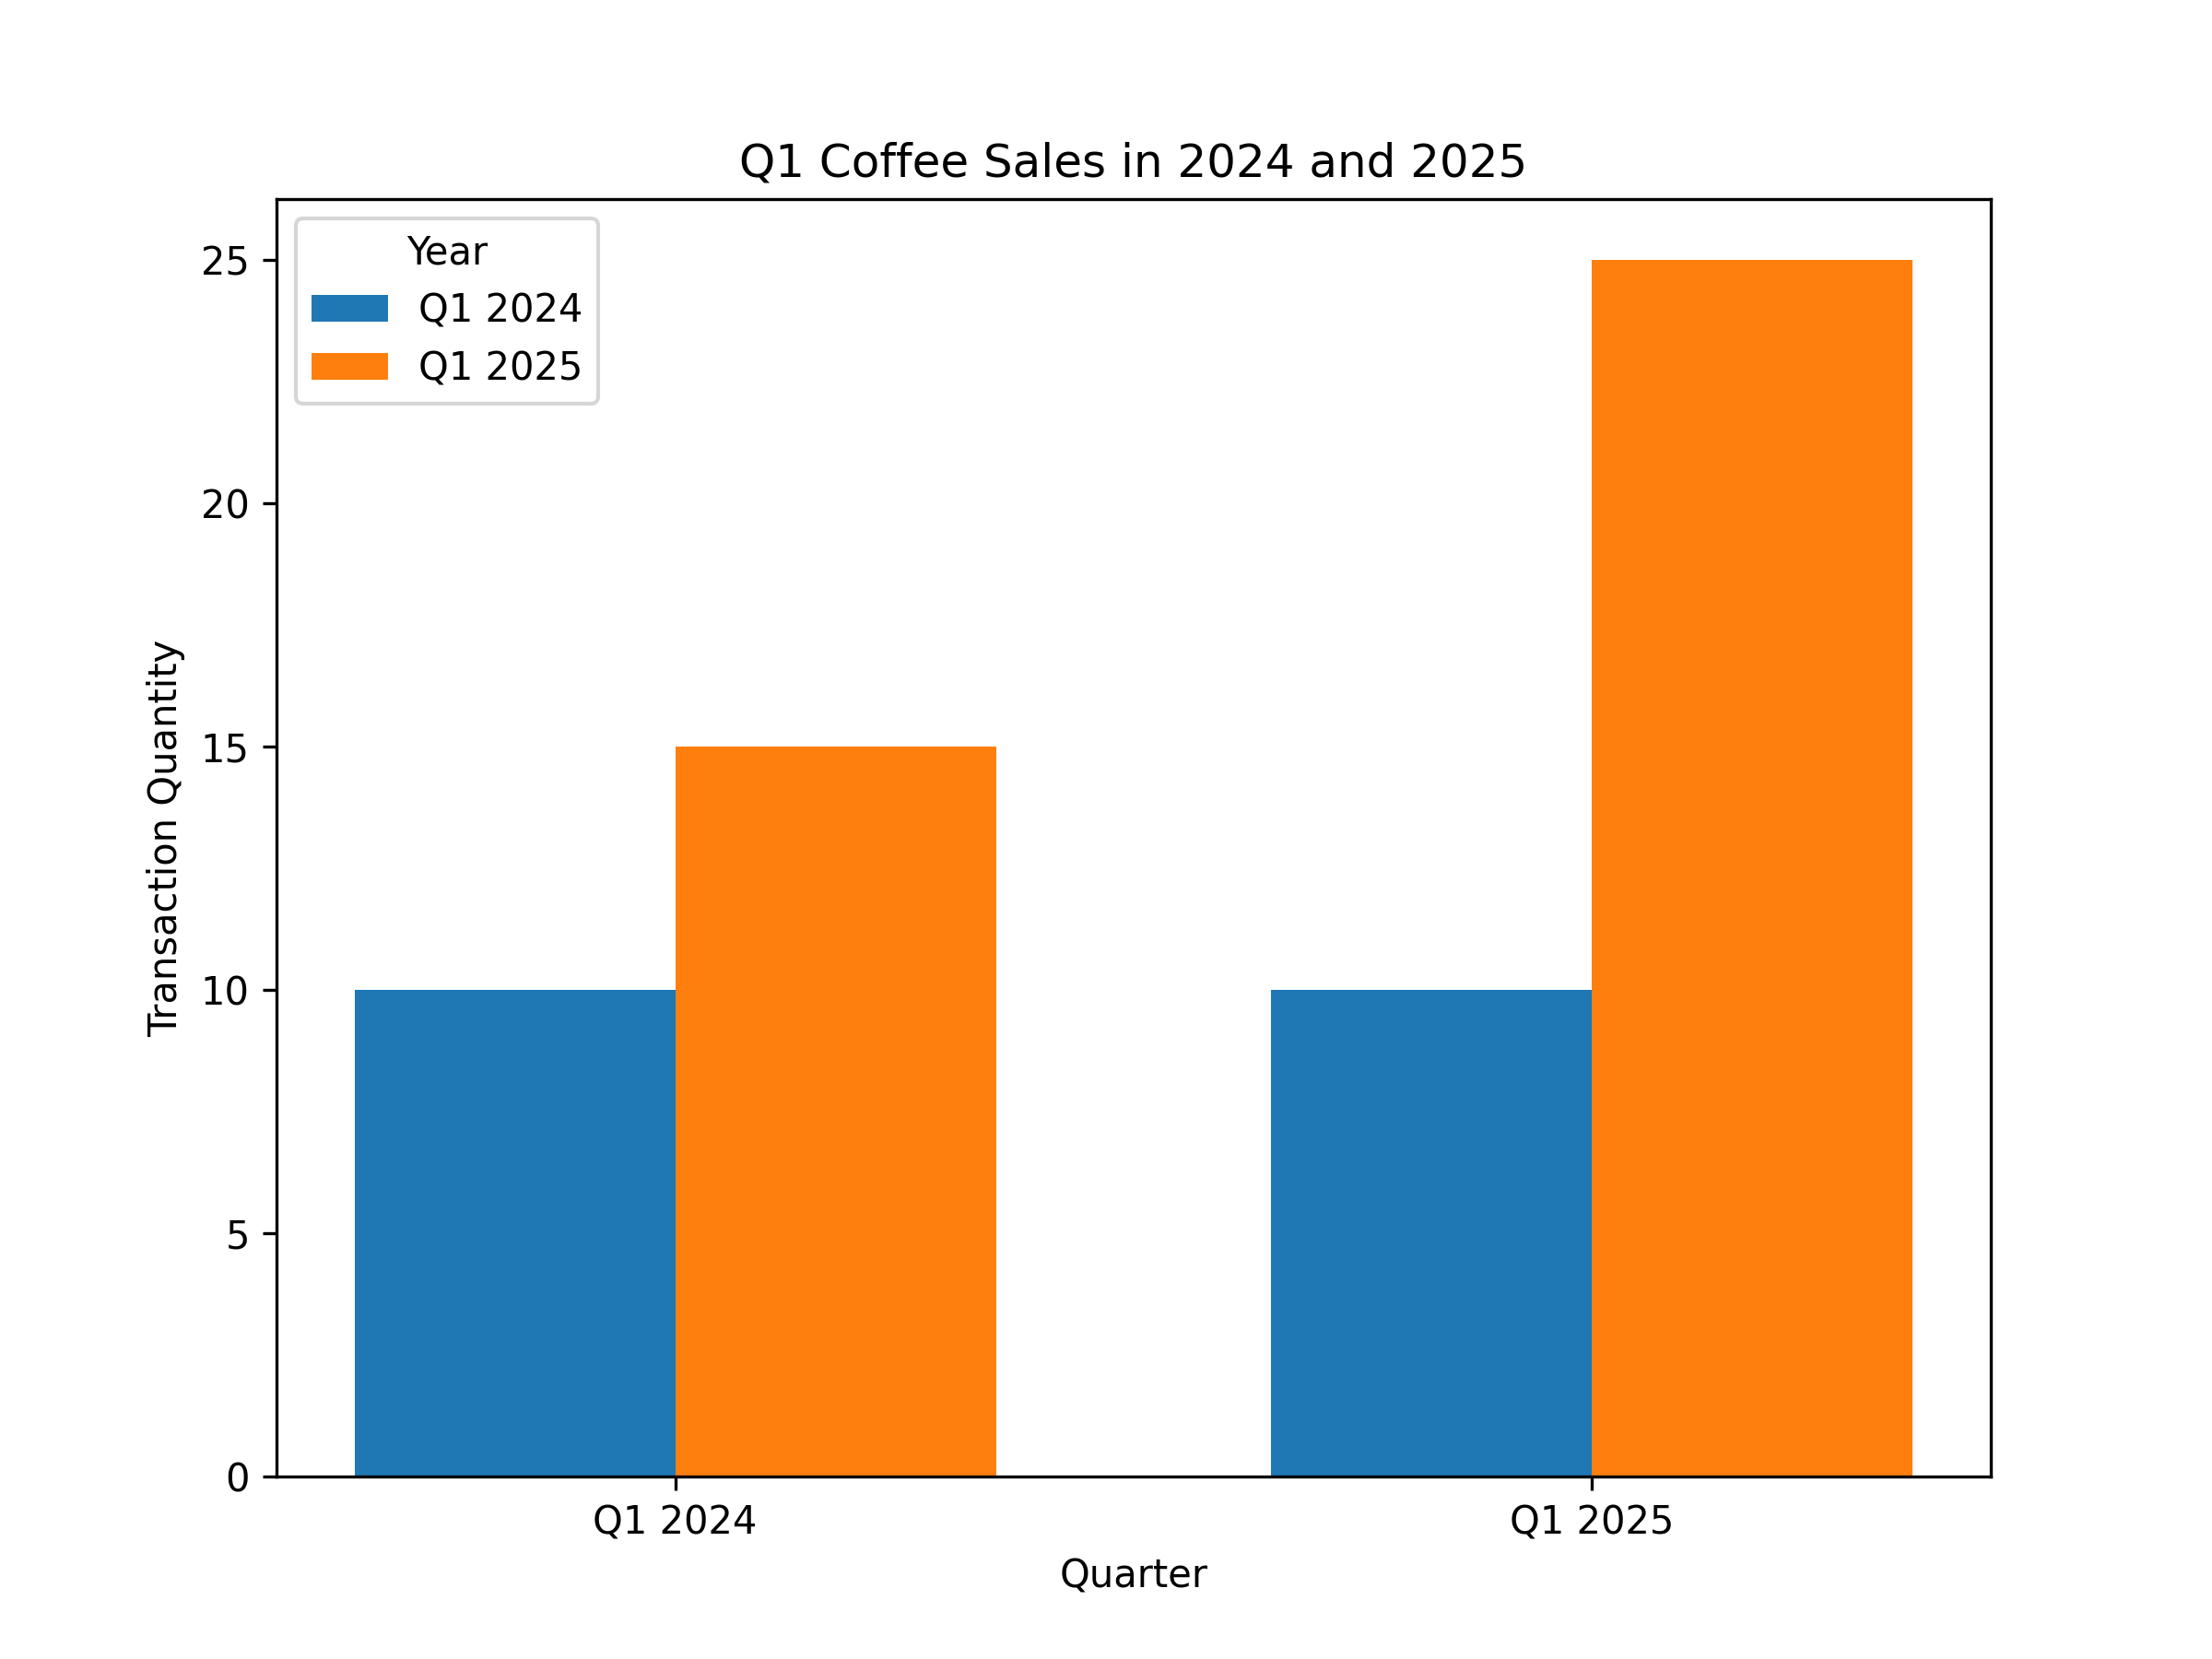


✅ Done! Compare chart_v1.png vs chart_v2.png


In [9]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image
from groq import Groq

# ====================== GROQ SETUP ======================
os.environ["GROQ_API_KEY"] = "gsk_wfuW5iS3NsyW1Sj8bur9WGdyb3FY6UvoX5jD8vBr7uA..."
client = Groq()

def ask_llm(prompt):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7
    )
    return response.choices[0].message.content

# ====================== LOAD EXCEL FILE ======================
print("Loading Coffee Shop Sales.xlsx ...")
df = pd.read_excel('Coffee Shop Sales.xlsx')

# Pre-process: Create year and quarter columns
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['quarter'] = df['transaction_date'].dt.quarter

print(f"✅ Excel file loaded successfully! Shape: {df.shape}")
print("Columns available:", list(df.columns))
display(df.head())

# ====================== INSTRUCTION ======================
instruction = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data."

print("\n🚀 Starting Agentic Chart Generation with Reflection...\n")

# ====================== STRONGER PROMPT (V1) ======================
prompt_v1 = f"""
You are a data visualization expert.

VERY IMPORTANT: Use ONLY these columns that exist in the DataFrame 'df':
{list(df.columns)}

Do NOT invent any column names like 'Q1', 'Sales', 'Region', etc.

Task: {instruction}

Write clean matplotlib code.
- Use 'year' and 'quarter' columns to filter Q1 2024 and Q1 2025.
- Save the plot as 'chart_v1.png' with dpi=300.
- Do not call plt.show().
- Close the plot with plt.close().

Return ONLY the code wrapped in <execute_python> ... </execute_python> tags.
No explanations outside the tags.
"""

code_v1 = ask_llm(prompt_v1)

print("=== V1 Code Generated ===\n")
display(Markdown(f"```python\n{code_v1}\n```"))

# Execute V1
exec_globals = {"df": df, "plt": plt}
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    exec(match.group(1).strip(), exec_globals)

display(Image('chart_v1.png', width=800))

# ====================== REFLECTION + V2 ======================
reflection_prompt = f"""
You are a senior data visualization expert.

Original instruction: {instruction}

Here is the first version code:
{code_v1}

The first chart is saved as chart_v1.png

Criticize the chart honestly and suggest improvements.
Then give much better matplotlib code for the second version.

Return in this exact format:
1. First line: a short feedback in JSON: {{"feedback": "your criticism here"}}
2. After a blank line, output only the improved code wrapped in:
<execute_python>
... improved code ...
</execute_python>

Save the new plot as 'chart_v2.png'
"""

response_v2 = ask_llm(reflection_prompt)

lines = response_v2.strip().splitlines()
feedback = lines[0] if lines else ""
code_v2 = "\n".join(lines[1:]) if len(lines) > 1 else response_v2

print("\n=== Reflection Feedback on V1 ===\n")
display(Markdown(feedback))

print("\n=== V2 Improved Code ===\n")
display(Markdown(f"```python\n{code_v2}\n```"))

match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    exec(match.group(1).strip(), exec_globals)

display(Image('chart_v2.png', width=800))

print("\n✅ Done! Compare chart_v1.png vs chart_v2.png")